In [1]:
import pandas as pd
import sqlite3
import seaborn as sns

In [2]:
# parameters
db = "gb.sqlite"

In [3]:
con = sqlite3.connect(db)
data = pd.read_sql(
    """
    SELECT * FROM query_result
    JOIN experiment ON query_result.experiment_id == experiment.id
""",
    con,
)

data = data.rename(columns={"iteration": "Iteration"})
data["embedding_model"] = data["embedding_model"].map(
    {"fingerprint": "Morgan Fingerprint", "chemberta-mtr": "ChemBERTa-2", "molformer": "MolFormer"}
)
data["Scoring"] = data["sampler"].map({
    "expected-improvement": "Expected Improvement",  "greedy": "Prediction", "random": "Random"
})
data["Iteration"] += 1

In [4]:
experiments = pd.read_sql(
    """
    SELECT * FROM experiment
""",
    con,
)

In [5]:
data.head()

,id,experiment_id,molecule,affinity,prediction_mean,prediction_std,Iteration,cluster,output_file_path,is_validation_result,...,sampler,surrogate,protein,seed,output_dir,n_clusters,simulator,bandit_confidence,job_id,Scoring
0,1,1,COC(=O)CCc1c[nH]c2ccccc12,-23.204418,-23.204418,0.001414,0,0,None,0,...,greedy,linear-empirical,4HW3,36899,gb,1,None,1.0,0,Prediction
1,2,1,CCc1c[nH]c2ccccc12,-21.583379,-23.204418,0.001414,1,0,None,0,...,greedy,linear-empirical,4HW3,36899,gb,1,None,1.0,0,Prediction
2,3,1,COC(=O)CCc1c[nH]c2c(C)cccc12,-26.531960,-23.204417,0.002154,2,0,None,0,...,greedy,linear-empirical,4HW3,36899,gb,1,None,1.0,0,Prediction
3,4,1,COC(=O)CCc1ccc(OC(=O)CCc2c[nH]c3c(C)cccc23)cc1,-26.879784,-26.531959,1.351940,3,0,None,0,...,greedy,linear-empirical,4HW3,36899,gb,1,None,1.0,0,Prediction
4,5,1,COC(=O)Cc1ccc(OC(=O)CCc2c[nH]c3c(C)cccc23)cc1,-27.412581,-26.708904,0.002128,4,0,None,0,...,greedy,linear-empirical,4HW3,36899,gb,1,None,1.0,0,Prediction


Text(0.5, 1.0, 'Average affinity')

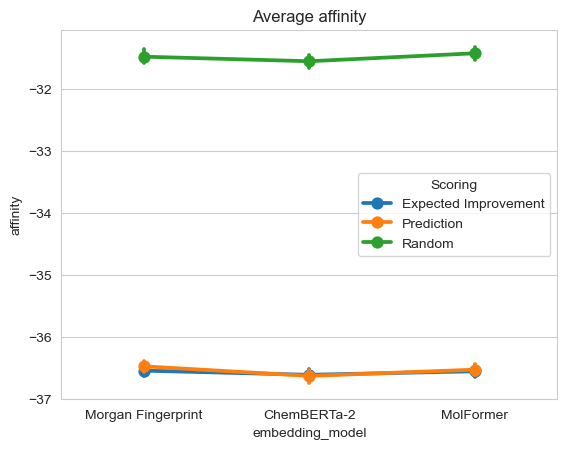

In [6]:
g = sns.pointplot(
    data,
    y="affinity",
    x="embedding_model",
    hue="Scoring",
    hue_order=sorted(data["Scoring"].unique())
)
g.set_title("Average affinity")

In [7]:
fp = f'../mmpbsa_dg_en_gb_avg.csv'
pool = pd.read_csv(fp)

In [8]:
import numpy as np

QUANTILES = [0.01, 0.05, 0.1]
quantiles = pool["target"].quantile(QUANTILES)
masks = {q: pool["target"] < val for q, val in quantiles.items()}
top_sets = {q: set(pool.loc[mask, "smiles"]) for q, mask in masks.items()}

results_dict = {q: [] for q in QUANTILES}

grouped = data.groupby(["experiment_id", "embedding_model", "Scoring", "surrogate"])
for name, group in grouped:
    for q in QUANTILES:
        top = top_sets[q]
        
        # Compute overlap
        overlap = group["molecule"].isin(top).cumsum()
        
        # Calculate Enrichment Factor for each iteration       
        recall = overlap / len(top)
        data_ratio = len(pool) / group["Iteration"].values
        enrichment_factor = recall * data_ratio
        max_enrichment_factor = data_ratio

        # Handle NaN and inf values
        enrichment_factor = np.where(np.isfinite(enrichment_factor), enrichment_factor, np.nan)
        max_enrichment_factor = np.where(np.isfinite(max_enrichment_factor), max_enrichment_factor, np.nan)
        

        q_results = pd.DataFrame({
            "experiment_id": name[0],
            "embedding_model": name[1],
            "Scoring": name[2],
            "surrogate": name[3],
            "Iteration": group["Iteration"],
            "overlap": overlap,
            "Enrichment Factor": enrichment_factor,
            "max_enrichment_factor": max_enrichment_factor,
            "Recall": recall,
            "Quantile": q
        })
        
        # Remove initial iteration, where EF is not defined
        q_results = q_results[(q_results["Iteration"] != 0)]
        
        results_dict[q].append(q_results)

results = pd.concat([pd.concat(results_dict[q]) for q in QUANTILES], ignore_index=True)

/tmp/ipykernel_28322/3458610528.py:20: RuntimeWarning: divide by zero encountered in divide
  data_ratio = len(pool) / group["Iteration"].values


In [9]:
results[results["Iteration"].isin((1000, 5000, 10_000))][["Quantile", "max_enrichment_factor"]].drop_duplicates()

,Quantile,max_enrichment_factor
999,0.01,60.0590
4999,0.01,12.0118
9999,0.01,6.0059
90999,0.05,60.0590
94999,0.05,12.0118
99999,0.05,6.0059
180999,0.10,60.0590
184999,0.10,12.0118
189999,0.10,6.0059


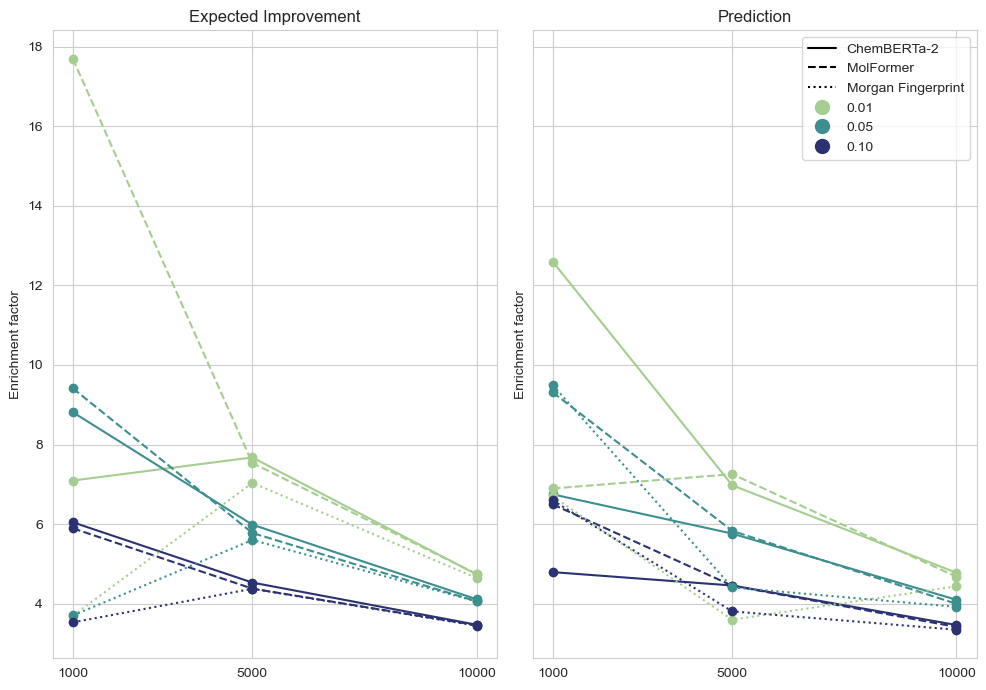

In [10]:
from matplotlib import pyplot as plt

from matplotlib import colormaps

cm = colormaps["crest"]
colors = cm(plt.Normalize()(QUANTILES))

fig, axes = plt.subplots(1, 2, figsize=(10, 7), sharey=True, sharex=True)

for sampler, ax1 in zip(sorted(results["Scoring"].unique()), axes):
    
    if sampler == "random":
        continue
    
    sampler_df = results[results["Scoring"] == sampler]
    for embedding_model, style in zip(sorted(results["embedding_model"].unique()), ["solid", "dashed", "dotted"]):
        emb_df = sampler_df[(sampler_df["embedding_model"] == embedding_model)]
        for quantile, color in zip(QUANTILES, colors):
            subset = emb_df[(emb_df["Quantile"] == quantile) & (emb_df["Iteration"].isin([1000, 5000, 9999]))]
            
            ax1.plot(
                subset["Iteration"], 
                subset["Enrichment Factor"], 
                label=f"{embedding_model}", 
                linestyle=style, 
                color=color, 
                marker="o"
            )
    
    ax1.set_title(sampler)
    ax1.set_xticks([1000, 5000, 10_000])
    ax1.set_ylabel("Enrichment factor")
    

import matplotlib.lines as mlines


model_handles = [mlines.Line2D([], [], linestyle=style, color='black', label=entry)
                 for entry, style in zip(sorted(results["embedding_model"].unique()), ["solid", "dashed", "dotted"])]

numeric_handles = [mlines.Line2D([], [], linestyle='none', marker='o', markersize=10,
                                 color=color, label=f'{entry:.2f}')
                   for entry, color in zip(QUANTILES, colors)]
    
axes[-1].legend(handles=model_handles + numeric_handles)
fig.tight_layout()

In [11]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

sns.set_style("whitegrid")
# sns.set_context("talk")

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    'font.size': 16, 
    "lines.linewidth": 2, 
    "axes.labelsize": 18,
    "axes.titlesize": 22
})

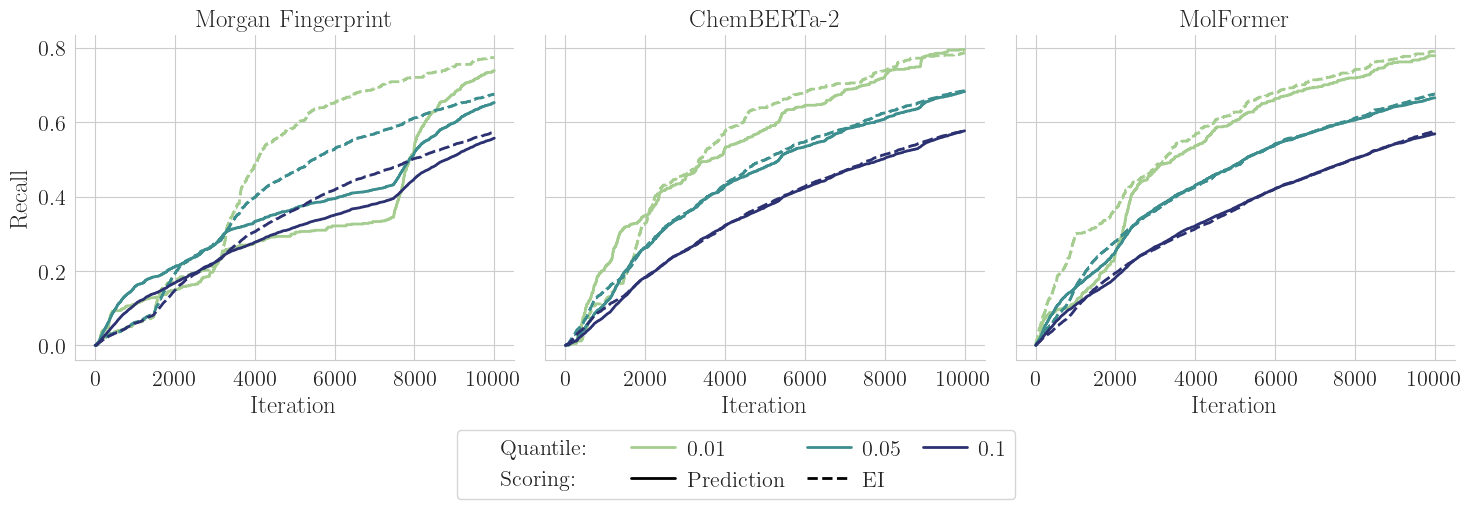

In [12]:
g = sns.relplot(
    results[results["surrogate"] != "constant"], 
    x="Iteration", y="Recall", 
    hue="Quantile",
    col="embedding_model",
    style="Scoring",
    kind="line",
    palette="crest",
    legend=False
)

g.set_titles("{col_name}")



legend_elements = [
    Line2D([0], [0], color='white', label='Quantile:', visible=False),
        Line2D([0], [0], color='white', label='Scoring:', visible=False),
    Line2D([0], [0], color=colors[0], label='0.01'),
        Line2D([0], [0], color='black', linestyle='-', label='Prediction'),
    Line2D([0], [0], color=colors[1], label='0.05'),
        Line2D([0], [0], color='black', linestyle='--', label='EI'),
    Line2D([0], [0], color=colors[2], label='0.1'),
        Line2D([0], [0], color='white', label='', visible=False),  # Invisible spacer
]

# Get the figure object
fig = plt.gcf()

# Add the combined legend to the figure
legend = fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.05), 
                    ncol=4, columnspacing=1, handletextpad=0.5)

# Adjust the appearance of the legend
for text in legend.get_texts():
    if text.get_text() in ['Quantile:', 'Scoring:']:
        text.set_ha('left')  # Align category labels to the left
        text.set_position((-20, 0))  # Adjust the position as needed

# Adjust the subplot layout to make room for the legend
plt.tight_layout()
plt.subplots_adjust(bottom=0.25)

g.savefig("bo_recall.pdf", format="pdf", dpi=300)
# g.savefig("bo_recall.png", dpi=300)

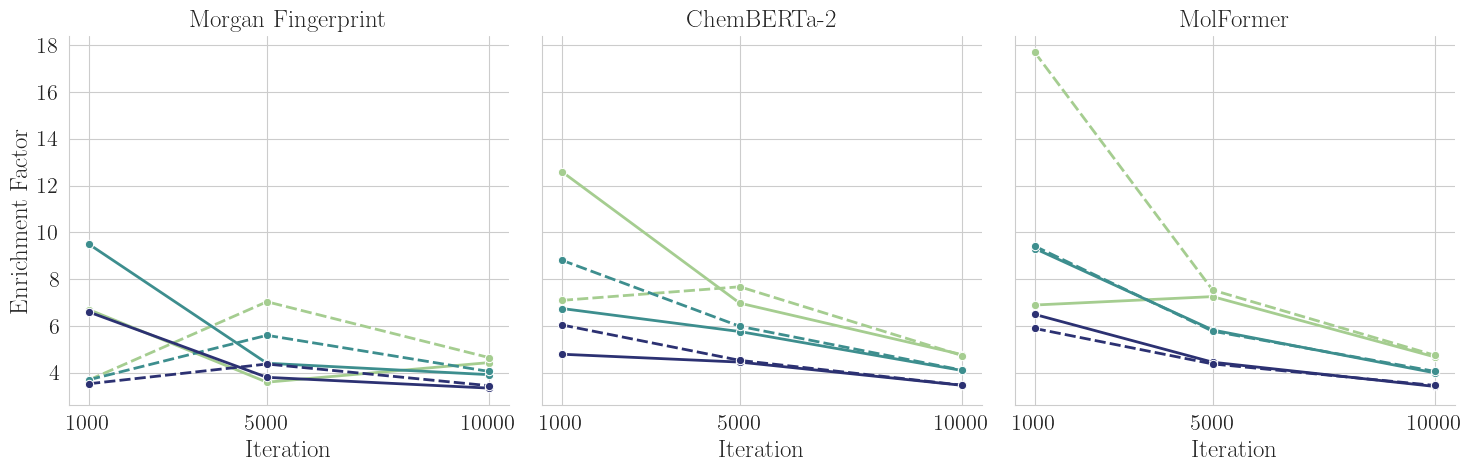

In [13]:
g = sns.relplot(
    results[(results["surrogate"] != "constant") & (results["Iteration"].isin([1000, 5000, 10_000]))], 
    x="Iteration", y="Enrichment Factor", 
    hue="Quantile",
    col="embedding_model",
    style="Scoring",
    kind="line",
    palette="crest",
    legend=False,
    marker="o"
)

g.set_titles(col_template="{col_name}")

g.map(lambda color: plt.gca().set_xticks([1000, 5000, 10_000]))
g.savefig("bo_ef.pdf", format="pdf", dpi=300)

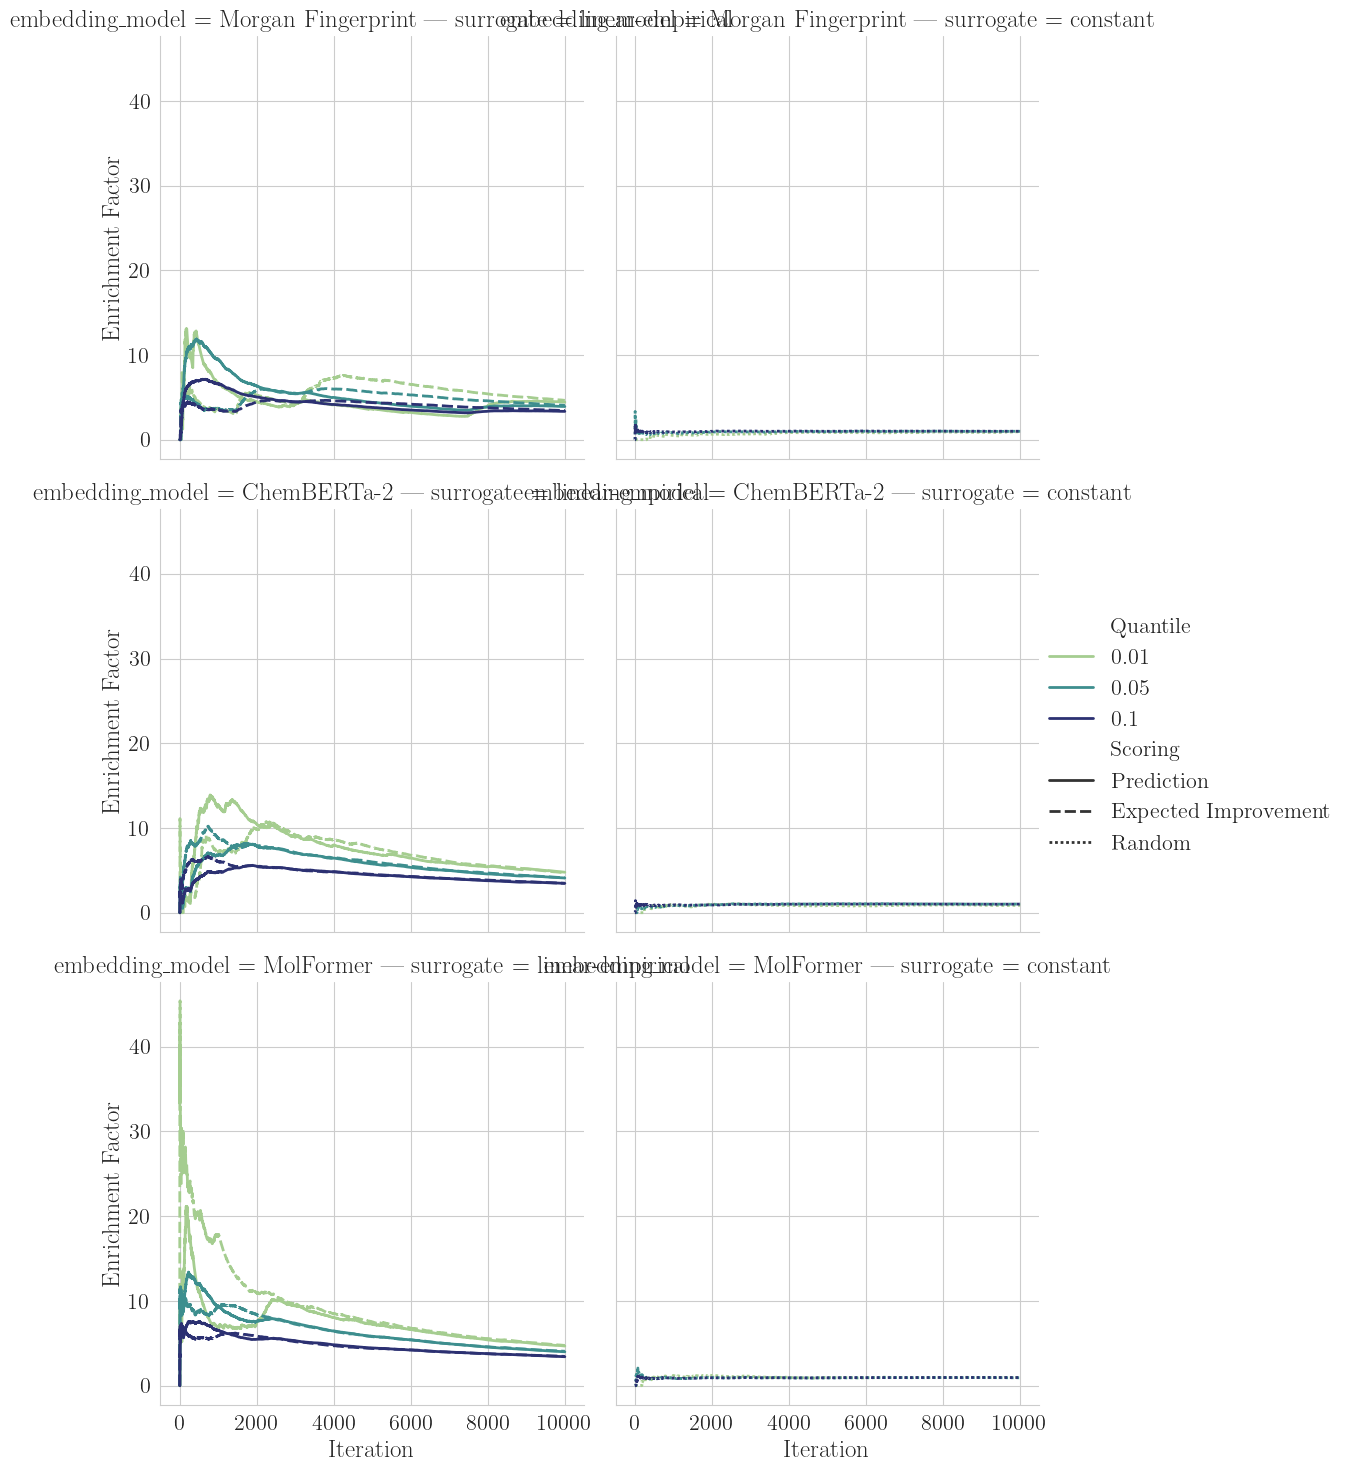

In [14]:
sns.relplot(
    results, 
    x="Iteration", y="Enrichment Factor", 
    hue="Quantile",
    row="embedding_model",
    style="Scoring",
    col="surrogate",
    kind="line",
    palette="crest"
)

In [15]:
X = results[results["Iteration"].isin([1000, 5000, 10_000])].sort_values(
    by=["embedding_model", "Quantile", "Scoring", "Iteration"]
)[["experiment_id", "embedding_model", "Scoring", "Iteration", "Quantile", "Recall", "Enrichment Factor"]]

X["Quantile"].unique()
pd.set_option("display.precision", 3)
X.to_csv("bo_gb.csv", index=False)

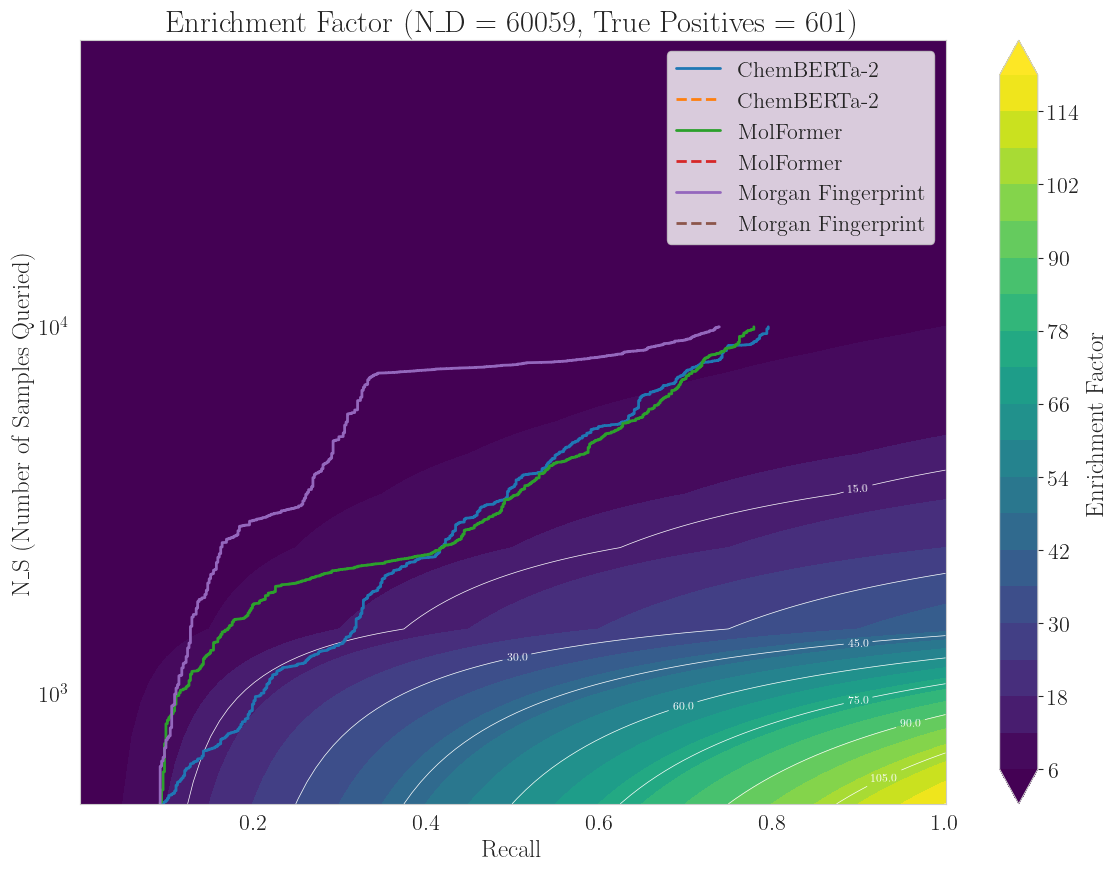

In [16]:
# Set parameters
N_D = pool.shape[0]  # Total number of samples in the dataset
true_positives = pool[pool["target"] < pool["target"].quantile(0.01)].shape[0]  # Number of true positive samples
N_S_range = np.arange(500, N_D + 1000, 1000)  # Range of N_S values

# Create a grid of values for Recall and N_S
recall = np.linspace(0.0001, 1, 100)
Recall, N_S = np.meshgrid(recall, N_S_range)

# Calculate Enrichment factor
# Enrichment factor = (P / N_S) / (TP / N_D) = (P/N_S) * (N_D/TP) = Recall * (N_D / N_S)
Enrichment = Recall * (N_D / N_S)

# Mask out zero values
mask = Enrichment > 0
Enrichment_masked = np.ma.masked_where(~mask, Enrichment)

# Create the plot
fig, ax = plt.subplots(figsize=(12, 9))

# Create a color-coded contour plot
contour = ax.contourf(Recall, N_S, Enrichment_masked, levels=20, cmap='viridis', extend='both')

# Add contour lines
contour_lines = ax.contour(Recall, N_S, Enrichment_masked, levels=10, colors='white', linewidths=0.5)
ax.clabel(contour_lines, inline=True, fontsize=8, fmt='%.1f')

# Set labels and title
ax.set_xlabel('Recall')
ax.set_ylabel('N_S (Number of Samples Queried)')
ax.set_title(f'Enrichment Factor (N_D = {N_D}, True Positives = {true_positives})')

# Add a colorbar
cbar = fig.colorbar(contour)
cbar.set_label('Enrichment Factor')

# Set y-axis to log scale
# results[
#     (results["Quantile"] == 0.01) 
#     & (results["embedding_model"] == "MolFormer") 
#     & (results["Scoring"] == "Prediction")
#     & (results["Iteration"] >= 500)
# ][["Recall", "Iteration"]].plot(x="Recall", y="Iteration", ax=ax)
# 
# results[
#     (results["Quantile"] == 0.01) 
#     & (results["embedding_model"] == "ChemBERTa-2") 
#     & (results["Scoring"] == "Prediction")
#     & (results["Iteration"] >= 500)
# ][["Recall", "Iteration"]].plot(x="Recall", y="Iteration", ax=ax)
# 
# 
# results[
#     (results["Quantile"] == 0.01) 
#     & (results["embedding_model"] == "Morgan Fingerprint") 
#     & (results["Scoring"] == "Prediction")
#     & (results["Iteration"] >= 500)
# ][["Recall", "Iteration"]].plot(x="Recall", y="Iteration", ax=ax)


subset = results[(results["Iteration"] >= 500) & (results["Quantile"] == 0.01) & (results["Scoring"] != "random")]

for embedding_model in sorted(subset["embedding_model"].unique()):
    for score_fn, linestyle in [("Prediction", "solid"), ("EI", "dashed")]:
        d = subset[(subset["embedding_model"] == embedding_model) & (subset["Scoring"] == score_fn)]
        ax.plot(
            d["Recall"], d["Iteration"], linestyle=linestyle, label=embedding_model
        )

ax.set_yscale('log')
ax.legend()


plt.tight_layout()